<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Tração e compressão de barras elásticas
## Vigas sujeitas à tracção/compressão. Parte II
## Problema 2 <a name="PIV93"></a>

Considere a barra rígida $ABC$ ligada a duas barras, $AD$ e $BF$, como se indica na figura. Todas as barras são fabricadas em aço macio que se admite ser um material elastoplástico ($E$= 210 GPa, $\sigma_Y$ = 250 MPa) mas a barra $AD$ tem uma secção transversal uniforme e rectangular com 20 mm $\times$ 6 mm enquanto a barra $BF$ é constituída por dois troços, $BE$ e $EF$, com área de secção respectivamente igual a $A_{BE} = 1200$ mm $^2$ e $A_{EF} = 2400$ mm $^2$. A intensidade da força $P$ aplicada em $C$ é gradualmente aumentada até que o deslocamento do ponto $C$ atinge 2,5 mm.

[a)](#A) Determine o valor máximo da força $P$ e a tensão normal em cada barra.

[b)](#B) Obtenha os alongamentos das duas barras quando a força $P$ está aplicada.

[c)](#C) Calcule as tensões residuais nas barras e o deslocamento residual do ponto $C$ quando a força $P$ é retirada.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i1.jpg"
width="550">

## Resolução

In [2]:
# ---------------------------
# DADOS do problema:
# unidades: mm, MPa, N

E, SigY = 210.e3, 250.
AAD, ABE, AEF = 20.*6, 1200., 2400.  # unidade: mm^2
LAD, LBE, LEF = 650., 150., 200. # barras verticais, unidade: mm
LAB, LBC = 250., 350. # barras horizontais
LAC = LAB + LBC
deltaCplast = 2.5
# ---------------------------

### a) Determine o valor máximo da força $P$ e a tensão normal em cada barra.<a name="A"></a> ([enunciatum](#PIV93))

Considere-se o comportamento elasto-plástico perfeito para o material de que é feito o sistema mecânico.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i2.jpg"
width="350" height="250">

Esta lei de plasticidade é traduzida por um diagrama tensão-deformação com dois tramos. O primeiro segmento de reta corresponde ao comportamento linear elástico, onde é válida a lei de Hooke: $\sigma = E \varepsilon$. Existe um ponto de inflexão no limite de elasticidade ($\sigma_Y$), acima do qual a tensão (força) máxima é mantida constante em função da deformação (incremento de variação de comprimento do elemento).

Conhecida a tensão de cedência do material ($\sigma_Y$) e as áreas de secção transversal das barras pode-se afetir os valores de força axial instalada no ponto limite de elasticidade:

\begin{equation*}
F_{AD}^\mathrm{max} = \sigma_Y A_{AD} \quad\wedge\quad
F_{BE}^\mathrm{max} = \sigma_Y A_{BE} \quad\wedge\quad
F_{EF}^\mathrm{max} = \sigma_Y A_{EF}
\end{equation*}

In [3]:
FADmax = SigY*AAD
FBEmax = SigY*ABE
FEFmax = SigY*AEF
print(f'FADmax (limite de elasticidade) = {FADmax*1e-3:.1f} kN')
print(f'FBEmax (limite de elasticidade) = {FBEmax*1e-3:.1f} kN')
print(f'FEFmax (limite de elasticidade) = {FEFmax*1e-3:.1f} kN')

FADmax (limite de elasticidade) = 30.0 kN
FBEmax (limite de elasticidade) = 300.0 kN
FEFmax (limite de elasticidade) = 600.0 kN


A lei constitutiva do material é descrita ao nível da barra por uma função força-variação de comprimento:

---------
Barra AD:
---------
(d,F)max AD = (0.774,30.0) [mm, kN]


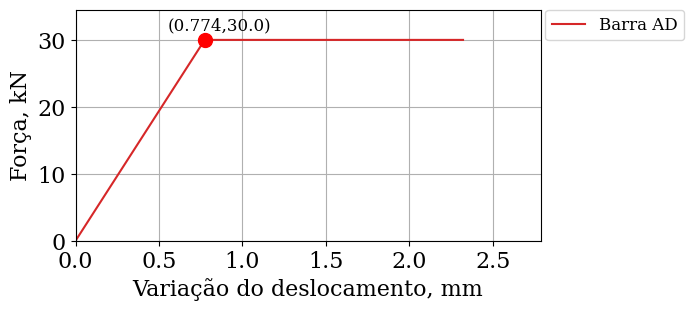

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})
# use LaTeX fonts in the plot
# plt.rc('text', usetex=True)
plt.rc('font', family='serif')

def plotCEP(x,y,lbl):
    fig = plt.figure(figsize=(6,3))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot([0,x ,3*x], [0,y,y], color='tab:red', label=lbl)
    ax.plot(x,y,marker='o',color='r', markersize=10)
    plt.text(x*.71, y*1.05, f'({x:.3f},{y:.1f})', fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize=12)
    plt.xlabel('Variação do deslocamento, mm')
    plt.ylabel('Força, kN')
    ax.set_xlim(0,1.8*2*x)
    ax.set_ylim(0,y*1.15)
    plt.grid()
    plt.show()

print('---------')
print('Barra AD:')
print('---------')
dADmax = FADmax*LAD/E/AAD
print(f'(d,F)max AD = ({dADmax:.3f},{FADmax*1e-3}) [mm, kN]')
plotCEP(dADmax,FADmax*1e-3,'Barra AD')


---------
Barra BE:
---------
(d,F)max BE = (7.738,300.0) [mm, kN]


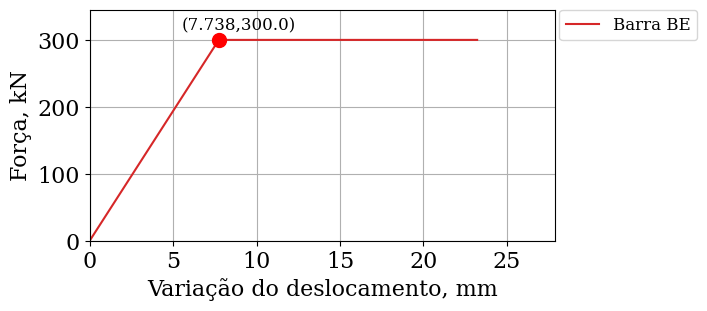

In [5]:
print('---------')
print('Barra BE:')
print('---------')
dBEmax = FBEmax*LAD/E/AAD
print(f'(d,F)max BE = ({dBEmax:.3f},{FBEmax*1e-3}) [mm, kN]')
plotCEP(dBEmax,FBEmax*1e-3,'Barra BE')

---------
Barra EF:
---------
(d,F)max EF = (15.476,600.0) [mm, kN]


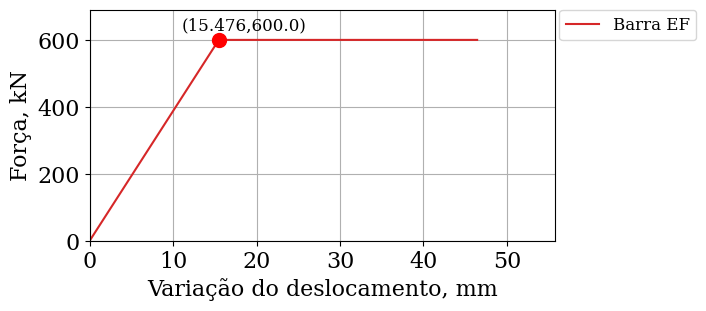

In [6]:
print('---------')
print('Barra EF:')
print('---------')
dEFmax = FEFmax*LAD/E/AAD
print(f'(d,F)max EF = ({dEFmax:.3f},{FEFmax*1e-3}) [mm, kN]')
plotCEP(dEFmax,FEFmax*1e-3,'Barra EF')

É de notar que a barra com menor força de cedência é a barra $AD$, pelo que, ocorrendo plasticidade, esta iniciará nesta barra.

##### Diagrama de corpo livre da barra rígida $ABC$

Considere-se o diagrama de corpo livre da barra rígida $ABC$ para o cenário de um carregamento para o qual a barra $AD$ está no limite de elasticidade ($F_{AD}^\mathrm{max}$). Que forças e deslocamentos ocorrerão na estrutura para este nível de carregamento? De notar que a barra $AD$ está à tração e a barra conjunta $BF$ está à compressão. No diagrama de corpo livre, a barra $ABC$ está submetida:

- A uma força vertical negativa $F_{AD}^\mathrm{max}$ aplica no ponto $A$ (no movimento de rotação da barra rígida, a barra $AD$ ficará submetida a uma força de tração; contudo, do ponto de vista da barra $ABC$, a barra $AD$ exercerá uma força de igual intensidade mas de sentido contrário);

- a uma força vertical positiva $F_{BF}$ aplicada no ponto $B$ (que irá balançar as forças $F_{AD}$ e $P$)

- a uma força $P$ vertical e negativa gradualmente  aplicada no ponto $E$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i3.jpg"
width="550">

A análise do equilíbrio permite escrever:

\begin{equation*}
\begin{cases}
+/\uparrow~:~\sum F_y=0 \quad&\Leftrightarrow\quad
-F_{AD} + F_{BF} -P = 0
~&\Leftrightarrow&~
F_{BF} = P + F_{AD} = \left(\displaystyle\frac{L_{AB}}{L_{BC}} + 1 \right)F_{AD} \\
+/\curvearrowleft~:\sum M_B = 0 \quad&\Leftrightarrow\quad
F_{AD} L_{AB} - P L_{BC} = 0
~&\Leftrightarrow&~
P = \left(\frac{L_{AB}}{L_{BC}}\right)F_{AD}
\end{cases}
\end{equation*}

Como se pode concluir este problema é estaticamente indeterminado. Para continuar a analisar o problema, é necessário acrescentar informação adicional. Nesse sentido, uma primeira análise pode ser a verificação da hipótese se alguma das barras do mecanismo entra no regime plástico, Admita-se que a resposta é sim, ou seja, que ocorre plastificação ou cedência de uma das barras em consequência da ação da força externa $P$.

- Hipótese: Uma das barras do sistema mecânico entra em plastificação pela ação da força $P$. Essa barra será a que tem menor força de cedência, correspondendo portanto à barra AD.

Assim, resultam os seguintes valores de força do sistema mecânico:

\begin{equation*}
\begin{cases}
F_{BF} &= P + F_{AD}^\mathrm{max} =
\left(\displaystyle\frac{L_{AB}}{L_{BC}} + 1 \right)F_{AD}^\mathrm{max}
= 51.4 \textrm{kN}\\
& P = \left(\displaystyle\frac{L_{AB}}{L_{BC}}\right)F_{AD}^\mathrm{max}
= 21.4 \textrm{kN}
\end{cases}
\end{equation*}

In [7]:
Pced = FADmax*LAB/LBC
print(f'P (FADmax) = {Pced*1e-3:.1f} kN')

FBF = Pced + FADmax
print(f'FBF (FADmax) = {FBF*1e-3:.1f} kN')


P (FADmax) = 21.4 kN
FBF (FADmax) = 51.4 kN


A resolução deste sistema de equações de equilíbrio permitiu analisar o estado da deformada do mecanismo para o estado limite de elasticidade da barra $AD$. Como esperado, a força axial aplicada na barra $BF$ (correspondendo ao estado de cedência de um dos elementos do mecanismo), de valor igual a 51.5 kN, é inferior ao limite elástico para essa barra conjunta, pelo que a esta não se deforma plasticamente.

O valor da força externa $P$ (gradualmente aplicado no ponto $E$ até este atingir um deslocamento vertical de 2.5 mm) irá aumentar deste a configuração inicial até ao valor máximo de 21.4 kN, a partir do qual a deformação do mecanismo ocorre a força (ou esforços) constante, devido exclusivamente à plasticidade da barra $AD$.

Para o mecanismo, o comportamento global linear elástico das barras que o constituem será garantido se a força externa aplicada satisfazer a inequação: $P \leq 21.4$  kN. Para o instante de cedência, as barras estarão sujeitas as tensões normais:

As tensões normais sentidas pelas barras neste instante de cedência serão:

In [8]:
sigADa = FADmax/AAD
sigBEa = FBF/ABE
sigEFa = FBF/AEF
print(f'sigADa (FADmax) = {sigADa:.2f} MPa (sig:cedência)')
print(f'sigBEa (FADmax) = {sigBEa:.2f} MPa')
print(f'sigEFa (FADmax) = {sigEFa:.2f} MPa')

sigADa (FADmax) = 250.00 MPa (sig:cedência)
sigBEa (FADmax) = 42.86 MPa
sigEFa (FADmax) = 21.43 MPa


### b) Obtenha os alongamentos das duas barras quando a força $P$ está aplicada.<a name="B"></a> ([enunciatum](#PIV93))

**Relações força-deslocamento**

Conhecidas as forças axiais aplicadas nas barras para o cenário de $F_{AD}^\mathrm{max}$ (limite do comportamento global linear elástico) é possível determinar o alongamento sofrido pelas barras.

 No domínio linear elástico, pilotado pelo limite de cedência da barra $AD$, os deslocamentos nos pontos $A$, $B$ e $C$ vêm:

- Ponto $A$:

\begin{equation*}
\delta_A^{\,\mathrm{max}}
= \frac{F_{AD}^{\,\mathrm{max}} L_{AD}}{A_{AD}E}
= 0.774~\textrm{mm (alongamento da barra, pela força de tração)}
\end{equation*}

In [9]:
deltaA = FADmax*LAD/AAD/E
print(f'deltaAmax = {deltaA:.4f} mm')

deltaAmax = 0.7738 mm


- Ponto $B$:

A expressão $\delta = PL/AE$ é válida para o caso particular em que a barra tem secção constante ($A$) ao longo do comprimento ($L$) e propriedades elásticas uniformes ($E$). Havendo variações de secção ao longo da barra, o deslocamento desta será determinado pelo princípio da sobreposição:

\begin{equation*}
\delta = \sum_i \frac{P_iL_i}{A_i E_i}
\end{equation*}

Pelo que, o alongamento no ponto $B$ é dado pelo sumatório dos alongamentos relativos das duas barras $BE$ e $EF$:

\begin{equation*}
\begin{aligned}
\delta_B &= \delta_{F_{BE}} + \delta_{F_{EF}} =
\frac{F_{BE} L_{BE}}{A_{BE}E} + \frac{F_{EF} L_{EF}}{A_{EF}E} = \frac{F_{BF}}{E}\left( \frac{L_{BE}}{A_{BE}} + \frac{L_{EF}}{A_{EF}}\right)
= 0.051~\textrm{mm (contração da barra, pela força de compressão)}
\end{aligned}
\end{equation*}

De notar que as barras em série têm o mesmo valor de esforço interno ($F_{BF}=F_{EF}=F_{EF}$) (diagrama de esforço axial uniforme ao longo das barras, i.e., o esforço axial é função apenas do equilíbrio e não de propriedades geométricas ou mecânicas da barras).

In [10]:
deltaB = FBF/E*(LBE/ABE + LEF/AEF)
print(f'deltaB (BE+EF) = {deltaB:.5f} mm')

deltaB (BE+EF) = 0.05102 mm


**Equações de compatibilidade de deslocamentos**

- Ponto $C$:

O deslocamento no ponto $C$ pode ser obtido pela geometria da deformada da barra rígida $ABC$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i4.jpg"
width="450" height="280">

A distância $x$, desconhecida nesta fase, é a distância que define o ponto de rotação da barra rígida. Pela igualdade de  triângulos, obtêm-se as seguinte relações de compatibilidade entre os deslocamentos das secções em análise:

\begin{equation*}
\begin{aligned}
\frac{\delta_A}{x} =
\frac{\delta_B}{L_{AB}-x} =
\frac{\delta_C}{L_{AC}-x}
\end{aligned}
\end{equation*}

Por eliminação da distância $x$, é possível expressar o deslocamento no ponto C de acordo com o seguinte desenvolvendo,

\begin{equation*}
\begin{cases}
\delta_A L_{AB} = x(\delta_A + \delta_B) \\
\delta_A L_{AC} = x(\delta_A + \delta_C) \\
\end{cases}
\quad\Leftrightarrow\quad
\begin{aligned}
\frac{\delta_A+\delta_B}{L_{AB}} =
\frac{\delta_A+\delta_C}{L_{AC}}
\end{aligned}
\end{equation*}

resolvendo para a variação de comprimento no ponto $C$:

\begin{equation*}
\delta_C = \frac{L_{AC}}{L_{AB}}(\delta_A+\delta_B) - \delta_A
= 1.206~\textrm{mm}
\end{equation*}

In [11]:
deltaC = (LAC/LAB)*(deltaA + deltaB) - deltaA
print(f'deltaC = {deltaC:.3f} mm')

deltaC = 1.206 mm


- Gráfico força externa aplicada e variação do deslocamento do ponto de aplicação na secção C

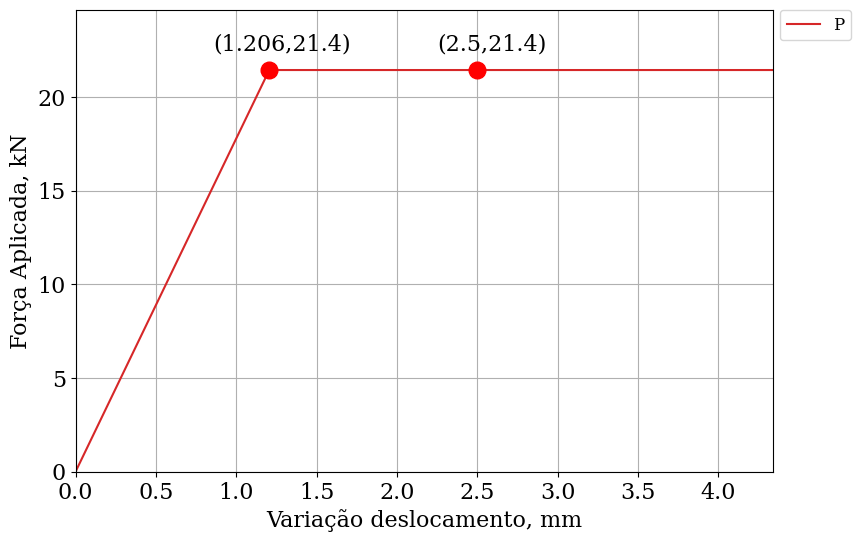

In [12]:
fig = plt.figure(figsize=(9,6))
x1, x2, y = deltaC, deltaCplast, Pced*1e-3
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,x1 , x2, 3*x2], [0,y,y,y], color='tab:red', label='P')
ax.plot(x1,y,marker='o',color='r', markersize=12)
plt.text(x1*.71, y*1.05, f'({x1:.3f},{y:.1f})', fontsize=16)
ax.plot(x2,y,marker='o',color='r', markersize=12)
plt.text(x2*.9, y*1.05, f'({x2:.1f},{y:.1f})', fontsize=16)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.xlabel('Variação deslocamento, mm')
plt.ylabel('Força Aplicada, kN')
ax.set_xlim(0,1.8*2*x1)
ax.set_ylim(0,y*1.15)
plt.grid()
plt.show()

**Análise do ponto de rotação**

De notar que o deslocamento do ponto $\delta_C=$ 1.206 mm corresponde ao cenário do limite de elasticidade para a barra $AD$.
Pelo que, para o valor enunciado de $\delta_C=$ 2.5 mm ocorrerá deformação plástica para a barra $AD.$

- Ponto centro de rotação da barra rígida ($F_{AD}^\mathrm{max}$): no cenário de $F_{AD}^\mathrm{max}$, a barra rígida $ABC$ irá rodar em torno de um ponto centro de rotação dado por:

\begin{equation*}
\frac{\delta_A}{x} =
\frac{\delta_C}{L_{AC}-x}
\quad\Leftrightarrow\quad
x = \frac{\delta_A}{\delta_A+\delta_C} L_{AC}
\end{equation*}

In [13]:
x = deltaA/(deltaA+deltaC)*LAC
print(f'x (coordenada do centro de rotação da placa rígida = {x:.3f} mm')

x (coordenada do centro de rotação da placa rígida = 234.536 mm


A partir de $F_{AD}^\mathrm{max}$, a deformada do mecanismo irá decorrer a esforços constantes, e o centro de rotação da barra rígida deslocar-se-á para o ponto $B$ de coordenada $L_{AB} = $ 250 mm.

- Diagrama força-deslocamento / tensão-deformação para a barra AD:

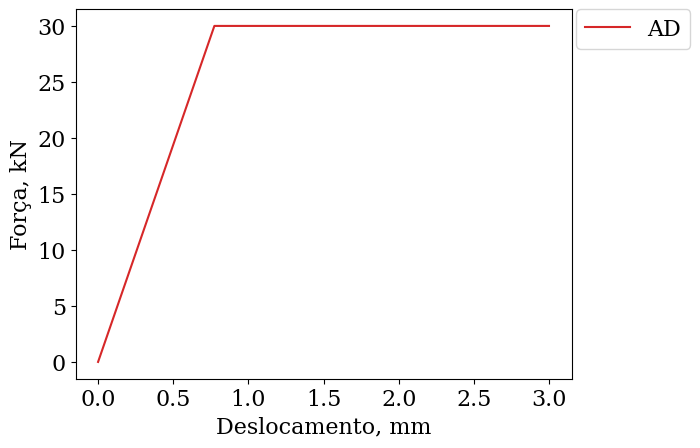

defA = 1190.48 micro def
tenA =  250.0  MPa


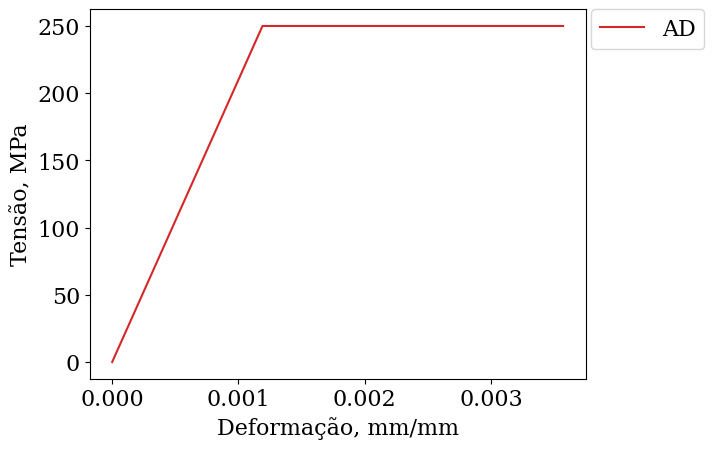

In [14]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=False)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,deltaA ,3], [0,FADmax*1e-3,FADmax*1e-3], color='tab:red', label='AD')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
# display the plot
plt.show()

defA = deltaA/LAD
print(f'defA = {defA*1e6:.2f} micro def')
tenA = FADmax/AAD
print('tenA = ',tenA,' MPa')
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,defA ,3*defA], [0,tenA,tenA], color='tab:red', label='AD')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deformação, mm/mm')
plt.ylabel('Tensão, MPa')
# display the plot
plt.show()

### c) Calcule as tensões residuais nas barras e o deslocamento residual do ponto $C$ quando a força $P$ é retirada.<a name="C"></a> ([enunciatum](#PIV93))

Considere-se agora o caso extremo em que o deslocamento do ponto $C$ é elevado para 2,5 mm. O que acontecerá aos deslocamentos e forças nos restantes pontos de interesse da barra rígida $ABC$?

De notar que a deformação do mecanismo ocorre a força constante entre o percurso $\delta_C \in [1.206\,,~2.5]$ mm.

Neste caso, o deslocamento do ponto $B$ permanece fixo ($F_{BF}$ constante) e a rotação geométrica do mecanismo ocorre em torno de $B$. A força constante, existirá um incremento contínuo de variação do comprimento da barra $AD$ sendo o valor do deslocamento total em $\delta_A^t$ (para $\delta_{C_p}=$ 2,5 mm) dado por (equação deduzida da geometria da deformada da barra rígida):

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i6b.png"
width="550" height="280">

\begin{equation*}
\begin{aligned}
\frac{\delta_A^t+\delta_B}{L_{AB}} =
\frac{\delta_{C_p} - \delta_{B}}{L_{BC}}
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
\delta_A^t = \frac{L_{AB}}{L_{BC}}\delta_{C_p} - \left(\frac{L_{AB}}{L_{BC}}+1 \right) \delta_B
\end{aligned}
\end{equation*}

In [15]:
n11 = (LAB/LBC)*deltaCplast
d11 = (LAB/LBC+1)*deltaB
deltaAtot2 = n11 - d11
print(f'deltaA tot (versão 2) = {deltaAtot2:.3f} mm')

deltaA tot (versão 2) = 1.698 mm


Ou, $\delta_A^t$ (para $\delta_{C_p}=$ 2,5 mm) dado por (equação deduzida da geometria da deformada da barra rígida):

\begin{equation*}
\begin{aligned}
\frac{\delta_A^t+\delta_B}{L_{AB}} =
\frac{\delta_A^t+\delta_{C_p}}{L_{AC}}
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
\delta_A^t = \frac{\delta_{C_p}L_{AB} - \delta_BL_{AC} }{L_{AC}-L_{AB}}
\end{aligned}
\end{equation*}

In [16]:
n1 = deltaCplast*LAB - deltaB*LAC
d1 = LAC-LAB
deltaAtot = n1/d1
print(f'deltaA tot = {deltaAtot:.3f} mm')

deltaA tot = 1.698 mm


O deslocamento do ponto $A$ para o limite de elasticidade tinha sido previamente calculado para $\delta_A^e = 0,7738$ mm. A força de cedência da barra $AD$ foi ultrapassada para um carregamento para o qual $\delta_C = 2,5$ mm, atingindo um alongamento total da barra de $\delta_A^\mathrm{tot} = 1,6983$ mm.

Desta forma ocorrerá no ponto $A$ uma deformação plástica. Este valor pode ser determinado considerando que a deformação total é o sumatório da deformação elástica com a deformação plástica:

\begin{equation*}
\delta_A^t = \delta_A^e + \delta_A^p
\quad\Leftrightarrow\quad
\delta_A^p = \delta_A^t - \delta_A^e
\end{equation*}

In [17]:
deltaAplas = deltaAtot - deltaA
print(f'deltaA plast  = {deltaAplas:.4f} mm')

deltaA plast  = 0.9244 mm


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P002_i5.jpg"
width="750">

Após remoção da força $P$ a barra rígida $ABC$ não irá voltar à sua configuração inicial de repouso (horizontal), porque ocorre uma deformação plástica da barra $AD$, traduzida por um aumento do seu comprimento inicial permanente. Pelo que, o deslocamento no ponto $A$ ($\delta_A^p$) irá provocar uma deformada ou rotação da barra rígida $ABC$ residual.

A barra $EF$ contudo recuperará totalmente (trabalha sempre no domínio linear elástico).

Neste caso a barra rígida $ABC$ irá rodar em torno do ponto $B$, que tem um deslocamento nulo (repouso), $\delta_B =0$ mm.

Assim sendo, têm-se:

\begin{equation*}
\begin{aligned}
\frac{\delta_A^p}{L_{AB}} =
\frac{\delta_{C}^R}{L_{BC}}
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
\delta_{C}^R = \delta_A^p \left(\frac{L_{BC}}{L_{AB}}\right)
\end{aligned}
\end{equation*}


In [18]:
deltaCred2b = deltaAplas*(LBC/LAB)
print(f'deltaCred (vers 2) = {deltaCred2b:.3f} mm')

deltaCred (vers 2) = 1.294 mm


ou de forma equivalente:

\begin{equation*}
\begin{aligned}
\frac{L_{AB}}{L_{AC}} =
\frac{\delta_A^p}{\delta_A^p+\delta_{C}^R}
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
\delta_{C}^R = \delta_A^p \left(\frac{L_{AC}}{L_{AB}}-1\right)
\end{aligned}
\end{equation*}

In [19]:
deltaCred2 = deltaAplas*(LAC/LAB -1)
print(f'deltaCred (vers 1) = {deltaCred2:.3f} mm')

deltaCred (vers 1) = 1.294 mm


In [22]:
Fresidual = deltaAplas*E*AAD/LAD
print(f'Fresidual = {Fresidual*1e-3:.2f} kN')

Sresidual = Fresidual/AAD
print(f'Sresidual = {Sresidual:.2f} MPa')


Fresidual = 35.84 kN
Sresidual = 298.67 MPa


#### Referências

[1] Beer, Johnston, DeWolf, Mazurek - Mechanics of Materials. 7ª Edição (2014). Secções 2.12: Plastic deformation e 2.13: Residual stresses.


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
